# LangGraph workflow work with tools
Before illustrating how <u>LangGraph Workflow</u> use LLM chat model to build an AI Agent.

## LangGraph workflow works with LLM chat model
<u>Langchain</u> input to LLM Chat Model by **Message** type. <u>LangGraph</u> uses similiar approach. 
### create an LLM chat model

In [2]:
### create an LLM chat model
from langchain_google_vertexai import ChatVertexAI

llm = ChatVertexAI(
    model_name="gemini-2.5-flash-lite",
    temperature=0.0
)

### LangChain interact with LLM Chat Model with Message
In LangChain, we can use **Message** which can be used to capture different roles with different conversation for LLM Chat Model. Every message have these components:
- content : content of the message
- name :  Specify the name of author
- response_metadata : optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)

In [3]:
from langchain_core.messages import AIMessage, HumanMessage, AnyMessage

messages = [
    AIMessage(content=f"Please tell me how can I help",name="LLMModel"),
    HumanMessage(content=f"I want to learn coding",name="Krish"),
    AIMessage(content=f"Which programming language you want to learn",name="LLMModel"),
    HumanMessage(content=f"I want to learn python programming language",name="Krish")
]

In [4]:
for msg in messages:
    msg.pretty_print()

================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Krish

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Krish

I want to learn python programming language


## Agent with tools
Create a tool as example for later usage.

In [5]:
def add(a:int,b:int)-> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b

There are two ways for an agent to use tool. 
1. LLM binding with tool
2. Using pre-build ToolNode

### LLM binding with tool

In [7]:
from rich import print as pprint

In [9]:
llm_with_tools=llm.bind_tools([add])
response=llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2",name="Krish")])
pprint(response)

AIMessage(
    content='',
    additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"a": 2.0, "b": 2.0}'}},
    response_metadata={
        'is_blocked': False,
        'safety_ratings': [],
        'usage_metadata': {
            'prompt_token_count': 38,
            'candidates_token_count': 5,
            'total_token_count': 43,
            'prompt_tokens_details': [{'modality': 1, 'token_count': 38}],
            'candidates_tokens_details': [{'modality': 1, 'token_count': 5}],
            'cached_content_token_count': 0,
            'cache_tokens_details': []
        },
        'finish_reason': 'STOP',
        'avg_logprobs': -0.01000421792268753,
        'model_name': 'gemini-2.5-flash-lite'
    },
    id='lc_run--019df8f2-f9fd-7830-8b0b-be2f0719e834-0',
    tool_calls=[
        {
            'name': 'add',
            'args': {'a': 2.0, 'b': 2.0},
            'id': 'b495a7bb-ff39-4dcc-89d0-b1cd30c9ba5d',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 38, 'output_tokens': 5, 'total_tokens': 43}
)

In [10]:
pprint(response.tool_calls)

[{'name': 'add', 'args': {'a': 2.0, 'b': 2.0}, 'id': 'b495a7bb-ff39-4dcc-89d0-b1cd30c9ba5d', 'type': 'tool_call'}]

Then we use Message to create State class.

In [18]:
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### node function wrapped LLM binded with tool

In [19]:
def node_func(state: State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

### create and compile the workflow graph

In [20]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

### adding nodes to the graph
graph_builder.add_node("llm_tool",node_func)

### connect nodes with edges
graph_builder.add_edge(START, "llm_tool")
graph_builder.add_edge("llm_tool", END)

### compile the graph
graph = graph_builder.compile()

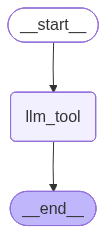

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (f97ff089-b693-47b6-a4b9-9a16e5910198)
 Call ID: f97ff089-b693-47b6-a4b9-9a16e5910198
  Args:
    a: 2.0
    b: 2.0


## Using pre-build ToolNode
We can use `langgraph.prebuilt.ToolNode` with `langgraph.prebuilt.tools_condition` and `StateGraph.add_conditional_edges()` to let LLM to use tool in the workflow. 
<br>We reuse `State` & `node_func`. 

In [24]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

graph_builder = StateGraph(State)

### adding nodes to the graph
graph_builder.add_node("llm_tool", node_func)
### add prebuild ToolNode
graph_builder.add_node("tools", ToolNode([add]))

### connect nodes with edges
graph_builder.add_edge(START, "llm_tool")
graph_builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
graph_builder.add_edge("tools", END)

### compile the graph
graph = graph_builder.compile()

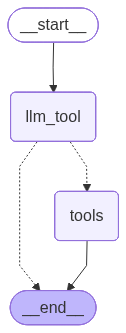

In [25]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (104bc1a7-aa22-4092-b58b-746571c0efcd)
 Call ID: 104bc1a7-aa22-4092-b58b-746571c0efcd
  Args:
    a: 2.0
    b: 2.0
================================= Tool Message =================================
Name: add

4


***
## Building LangGraph workflow with chat model and multiple tools
We are going to build an workflow with tool capabilities from arxiv, wikipedia search, GoGoDuckSeach

### Prepare tools for workflow

In [7]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun,DuckDuckGoSearchRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper,DuckDuckGoSearchAPIWrapper
from langchain_community.tools import DuckDuckGoSearchRun

#### testing arxiv search tool

In [5]:
arxiv_tool = ArxivQueryRun(api_wrapper=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500))
print(arxiv_tool.name)

arxiv


In [16]:
arxiv_tool.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

#### testing wikipedia search tool

In [11]:
wiki_tool=WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500))
print(wiki_tool.name)

wikipedia


In [17]:
wiki_tool.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation me'

#### testing DuckDuckGo search tool

In [34]:
duckduckgo_tool = DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(max_results=3))
print(duckduckgo_tool.name)

duckduckgo_search


In [ ]:
duckduckgo_tool.invoke("Nvidia News")

### combine all tools and bind them to LLM model 

In [23]:
tools = [arxiv_tool, wiki_tool, duckduckgo_tool]

In [24]:
llm_with_tools = llm.bind_tools(tools)

### Build the workflow

In [25]:
### state 
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [26]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

### node function
def node_func(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

### workflow graph
graph_builder = StateGraph(State)

### adding nodes to the graph
graph_builder.add_node("tool_calling_llm", node_func)
### add prebuild ToolNode
graph_builder.add_node("tools", ToolNode(tools))

### connect nodes with edges
graph_builder.add_edge(START, "tool_calling_llm")
graph_builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
graph_builder.add_edge("tools", END)

### compile the graph
graph = graph_builder.compile()

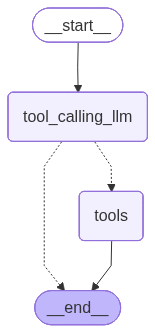

In [27]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
from langchain_core.messages import AIMessage, HumanMessage

In [31]:
responses=graph.invoke({"messages":HumanMessage(content="'1706.03762'")})
for res in responses['messages']:
    res.pretty_print()

================================ Human Message =================================

'1706.03762'
================================== Ai Message ==================================
Tool Calls:
  arxiv (c673249d-4e5f-4502-a30d-8fd758228ebe)
 Call ID: c673249d-4e5f-4502-a30d-8fd758228ebe
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [32]:
responses=graph.invoke({"messages":HumanMessage(content="check with WIKI for 'What is machine learning?'")})
for res in responses['messages']:
    res.pretty_print()

================================ Human Message =================================

check with WIKI for 'What is machine learning?'
================================== Ai Message ==================================
Tool Calls:
  wikipedia (605540bb-d39a-45c7-9fe4-8f40ffaa3320)
 Call ID: 605540bb-d39a-45c7-9fe4-8f40ffaa3320
  Args:
    query: What is machine learning?
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation me


In [33]:
responses=graph.invoke({"messages":HumanMessage(content="Nvidia News")})
for res in responses['messages']:
    res.pretty_print()

================================ Human Message =================================

Nvidia News
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (9c1df6c1-ecb1-44fa-bbbe-f4198c593596)
 Call ID: 9c1df6c1-ecb1-44fa-bbbe-f4198c593596
  Args:
    query: Nvidia News
================================= Tool Message =================================
Name: duckduckgo_search

NVIDIA Launches Ising, the World's First Open AI Models to Accelerate the Path to Useful Quantum Computers NVIDIA today announced the world's first family of open source quantum AI models, NVIDIA Ising, designed to help researchers and enterprises build quantum processors capable of running useful applications. Corning is opening three new advanced manufacturing plants in the U.S. dedicated entirely to optical technologies for Nvidia. See the latest on Nvidia. From breaking news to in-depth reporting, Bloomberg tracks the full story in real time.
